<a href="https://colab.research.google.com/github/JosemCastano17/SyS-2025-ll/blob/main/Detector_Genero_Musical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1) Descarga del Excel desde tu Google Sheet (copiar en una celda nueva)

In [16]:
# Descarga directa desde Google Sheets exportando a Excel (.xlsx)
# Pega aquí tu enlace de Google Sheets:
SHEETS_LINK = "https://docs.google.com/spreadsheets/d/1fn8uVSu1h7OQae-0pgphqdKOJZMimLLR/edit?usp=sharing&ouid=102376190649773949531&rtpof=true&sd=true"

import re, os, sys, subprocess, pandas as pd

# Extraer el ID de la hoja
m = re.search(r"/d/([a-zA-Z0-9_-]+)", SHEETS_LINK)
assert m, "No se pudo extraer el ID de la Google Sheet. Revisa el enlace."
SHEET_ID = m.group(1)

# Construir la URL de exportación a .xlsx
EXPORT_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=xlsx"

# Descargar usando wget
!wget -q --no-check-certificate "$EXPORT_URL" -O canciones.xlsx

# Verificar
import os
assert os.path.exists("canciones.xlsx") and os.path.getsize("canciones.xlsx") > 0, "No se pudo descargar canciones.xlsx."
print("Descarga OK -> canciones.xlsx")


Descarga OK -> canciones.xlsx


#2. Cargar y preparar el listado

In [17]:
import pandas as pd

file_ = "canciones.xlsx"  # Excel descargado
X = pd.read_excel(file_)
print("Columnas detectadas:", list(X.columns))
display(X.head())


#   link  -> URL de YouTube
#   band  -> banda / artista
#   type  -> género en texto
#   type_num -> género en número (1, 2, ...)
#
# Si tus nombres no coinciden, este bloque intenta mapearlos automáticamente.

colmap = {c.lower(): c for c in X.columns}

# Asegurar 'link'
if 'link' not in X.columns:
    for cand in ('url','enlace','youtube','youtube_url','video','video_url'):
        if cand in colmap:
            X = X.rename(columns={colmap[cand]: 'link'})
            break
assert 'link' in X.columns, "Falta la columna 'link' (enlace de YouTube). Corrige en la hoja o renombra aquí."

# Asegurar 'band'
if 'band' not in X.columns:
    for cand in ('banda','artista','artist','autor','grupo'):
        if cand in colmap:
            X = X.rename(columns={colmap[cand]: 'band'})
            break
    if 'band' not in X.columns:
        X['band'] = 'unknown'

# Asegurar 'type'
if 'type' not in X.columns:
    for cand in ('genre','genero','género','genero_musical','tipo'):
        if cand in colmap:
            X = X.rename(columns={colmap[cand]: 'type'})
            break
    if 'type' not in X.columns:
        # Si no existe, crea una genérica para no romper el flujo (ideal: tenerla bien en la Sheet)
        X['type'] = 'G1'

# Asegurar 'type_num'
if 'type_num' not in X.columns:
    tipos = list(pd.Series(X['type'].astype(str)).unique())
    tipo_to_num = {t: i+1 for i, t in enumerate(tipos)}
    X['type_num'] = X['type'].map(tipo_to_num)

print("Columnas tras ajuste:", list(X.columns))
display(X.head())


Columnas detectadas: ['link', 'band', 'type', 'type_num']


,link,band,type,type_num
0,https://www.youtube.com/watch?v=1BNYhpyNPiI,Pan-Pot,Techno,1
1,https://www.youtube.com/watch?v=8eUw9H6oufk,indira paganotto,Techno,1
2,https://www.youtube.com/watch?v=FZjPMsly2Mk,indira paganotto,Techno,1
3,https://www.youtube.com/watch?v=LUZYejJgxJQ,999999999,Techno,1
4,https://www.youtube.com/watch?v=vGEE1G8lY-A,Altinbas · Cirkle,Techno,1


Columnas tras ajuste: ['link', 'band', 'type', 'type_num']


,link,band,type,type_num
0,https://www.youtube.com/watch?v=1BNYhpyNPiI,Pan-Pot,Techno,1
1,https://www.youtube.com/watch?v=8eUw9H6oufk,indira paganotto,Techno,1
2,https://www.youtube.com/watch?v=FZjPMsly2Mk,indira paganotto,Techno,1
3,https://www.youtube.com/watch?v=LUZYejJgxJQ,999999999,Techno,1
4,https://www.youtube.com/watch?v=vGEE1G8lY-A,Altinbas · Cirkle,Techno,1


#3. Instalar librerías necesarias para descarga y audio



In [18]:
# Instala las librerías necesarias.

!python3 -m pip install --quiet --force-reinstall https://github.com/yt-dlp/yt-dlp/archive/master.tar.gz
!pip -q install soundfile browser-cookie3 umap-learn scikit-learn librosa==0.10.1
# ffmpeg suele estar en Colab; si no, descomenta:
# !apt-get -y -qq install ffmpeg



  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


#4. Cargar cookies del navegador (si están disponibles) y configurar yt_dlp



In [19]:
import os
import yt_dlp as youtube_dl
import browser_cookie3

# Intento de obtener cookies desde Firefox/Chrome (puede no funcionar en Colab; no es obligatorio)
cookies = None
try:
    cookies = browser_cookie3.firefox()
except:
    print("No se pueden descargar cookies desde Firefox. Intentando Chrome...")
    try:
        cookies = browser_cookie3.chrome()
    except:
        print("No se pueden descargar cookies desde Chrome. Continuando sin cookies.")
        cookies = None

def download_ytvid_as_mp3(video_url, name):
    """
    Descarga el mejor audio disponible y lo guarda como MP3.
    Luego, el cuaderno lo convertirá a WAV con ffmpeg.
    """
    options = {
        'format': 'bestaudio/best',
        'keepvideo': False,
        'outtmpl': f'{name}.%(ext)s',  # yt-dlp decide la extensión (m4a/webm/opus/mp3)
        'quiet': False
    }
    # Nota: yt_dlp acepta cookiefile (ruta a archivo). browser_cookie3 retorna un jar en memoria.
    # En Colab no solemos tener cookies del usuario, por lo que normalmente se descarga sin cookies.
    with youtube_dl.YoutubeDL(options) as ydl:
        try:
            info = ydl.extract_info(video_url, download=True)
            print(f"Download complete: {info.get('title','(sin título)')}")
        except Exception as e:
            print(f"Error descargando {video_url}: {e}")
            raise


No se pueden descargar cookies desde Firefox. Intentando Chrome...
No se pueden descargar cookies desde Chrome. Continuando sin cookies.


#5. Construcción de la base de datos de características (features)

In [20]:
# Esta celda:
#  - Recorre el listado (en RUTA_LISTADO),
#  - Descarga cada audio,
#  - Extrae 5 s,
#  - Calcula la FFT,
#  - Guarda un CSV con "path", "genre" y "feature_json".

import pandas as pd

def cargar_listado(ruta):
    if ruta.lower().endswith((".xlsx", ".xls")):
        df = pd.read_excel(ruta)
    else:
        df = pd.read_csv(ruta)
    df.columns = [c.strip() for c in df.columns]
    assert COLUMNA_URL in df.columns,    f"No se encuentra la columna '{COLUMNA_URL}'."
    assert COLUMNA_GENERO in df.columns, f"No se encuentra la columna '{COLUMNA_GENERO}'."
    return df

def construir_features():
    df = cargar_listado(RUTA_LISTADO)
    registros = []
    for i, row in df.iterrows():
        url = str(row[COLUMNA_URL]).strip()
        genero = str(row[COLUMNA_GENERO]).strip()
        if not url or not genero or url.lower() == "nan" or genero.lower() == "nan":
            continue
        try:
            base = f"{genero}_{i:05d}"
            wav_path = descargar_audio_youtube(url, out_dir=DATA_DIR, basename=base)
            y, _ = extraer_segmento_5s(wav_path)
            feat = fft_magnitud(y)
            registros.append({
                "path": wav_path,
                "genre": genero,
                "feature_json": vector_a_str(feat)
            })
            print("OK:", wav_path)
        except Exception as e:
            print("ERROR con", url, "->", e)

    out = pd.DataFrame(registros)
    out.to_csv(FEATURES_CSV, index=False)
    print("Guardado:", FEATURES_CSV, "| Registros:", len(out))

# Ejecute la siguiente línea para construir los features.
# Dependiendo de la cantidad de enlaces, puede tardar.
# construir_features()


#5. Crear carpeta de resultados y descargar/convertir audios



In [21]:
import subprocess

# crear carpeta resultados
try:
    os.mkdir('results')
except:
    print("Carpeta 'results' ya existe")

# recorrer excel con videos
N, P = X.shape
for n in range(N):
    print(f"video {n+1} de {N}")
    print(f"link: {X.loc[n,'link']}")
    print(f"band: {X.loc[n,'band']}")
    print(f"type: {X.loc[n,'type']}")
    name_ = f"results/{X.loc[n,'band']}_{n}_{X.loc[n,'type_num']}"  # nombre base para archivos

    # Descargar mejor audio (puede quedar .m4a, .webm, .opus, .mp3)
    try:
        download_ytvid_as_mp3(X.loc[n,'link'], name_)
    except Exception as e:
        print(f"Saltando video por error de descarga: {e}")
        continue

    # Detectar archivo descargado (cualquiera de estos formatos)
    base = os.path.basename(name_)
    found = None
    for ext in ('.mp3','.m4a','.webm','.opus'):
        cand = name_ + ext
        if os.path.exists(cand):
            found = cand
            break

    if not found:
        print("No se encontró el archivo de audio descargado para convertir a WAV. Se omite.")
        continue

    # Convertir a WAV estéreo a 48 kHz con ffmpeg
    wav_out = name_ + ".wav"
    cmd = ['ffmpeg', '-y', '-i', found, '-ac', '2', '-ar', '48000', wav_out]
    try:
        subprocess.run(cmd, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    except subprocess.CalledProcessError as e:
        print("Error convirtiendo a WAV:", e.stderr.decode()[:2000])
        continue

    print("OK ->", wav_out)


Carpeta 'results' ya existe
video 1 de 15
link: https://www.youtube.com/watch?v=1BNYhpyNPiI
band: Pan-Pot
type: Techno
[youtube] Extracting URL: https://www.youtube.com/watch?v=1BNYhpyNPiI
[youtube] 1BNYhpyNPiI: Downloading webpage


[youtube] 1BNYhpyNPiI: Downloading android sdkless player API JSON
[youtube] 1BNYhpyNPiI: Downloading web safari player API JSON


[youtube] 1BNYhpyNPiI: Downloading m3u8 information


[info] 1BNYhpyNPiI: Downloading 1 format(s): 251
[download] results/Pan-Pot_0_1.webm has already been downloaded
[download] 100% of    6.17MiB
Download complete: Pan-Pot - Nightcode (Extended Mix) [Second State | HUMAN]
OK -> results/Pan-Pot_0_1.wav
video 2 de 15
link: https://www.youtube.com/watch?v=8eUw9H6oufk
band: indira paganotto
type: Techno
[youtube] Extracting URL: https://www.youtube.com/watch?v=8eUw9H6oufk
[youtube] 8eUw9H6oufk: Downloading webpage


[youtube] 8eUw9H6oufk: Downloading android sdkless player API JSON
[youtube] 8eUw9H6oufk: Downloading web safari player API JSON


...

[youtube] wic3fFRkgKs: Downloading m3u8 information


[info] wic3fFRkgKs: Downloading 1 format(s): 251
[download] results/Nanø Rinnegatø_13_1.webm has already been downloaded
[download] 100% of    5.91MiB
Download complete: Nanø Rinnegatø - Kurayami No Sonata
OK -> results/Nanø Rinnegatø_13_1.wav
video 15 de 15
link: https://www.youtube.com/watch?v=g8OoUK6qjJ8
band: Setaoc Mass
type: Techno
[youtube] Extracting URL: https://www.youtube.com/watch?v=g8OoUK6qjJ8
[youtube] g8OoUK6qjJ8: Downloading webpage


[youtube] g8OoUK6qjJ8: Downloading android sdkless player API JSON
[youtube] g8OoUK6qjJ8: Downloading web safari player API JSON


[youtube] g8OoUK6qjJ8: Downloading m3u8 information


[info] g8OoUK6qjJ8: Downloading 1 format(s): 251
[download] results/Setaoc Mass_14_1.webm has already been downloaded
[download] 100% of    6.56MiB
Download complete: Setaoc Mass - True Lies [SK11006]
OK -> results/Setaoc Mass_14_1.wav


#6. Listar WAVs y cargar en memoria por segmentos

In [22]:
# lista de archivos .wav en 'results/'
path = 'results/'
wav_files = [f for f in os.listdir(path) if f.endswith('.wav')]
print("Cantidad de WAVs encontrados:", len(wav_files))
import numpy as np
import soundfile as sf
from scipy.signal import resample_poly

fs = 48000                 # frecuencia objetivo
tl = np.array([30,40,50,60,70,80])  # inicios de cada segmento dentro de la canción [s]
ts = 5                     # duración de cada segmento [s]
segment_length_fs = int(ts * fs)

Ns = len(wav_files) * len(tl)       # cantidad teórica de segmentos
x_t = np.zeros((Ns, segment_length_fs, 2), dtype=np.float32)  # Ns segmentos, muestras, 2 canales
label = np.zeros((Ns,1), dtype=np.int32)
type_c = X['type'].astype(str).unique()
name_c = []

i = 0
for name in wav_files:
    x, fs_i = sf.read(os.path.join(path, name))
    # Asegurar formato [n_muestras, 2]
    if x.ndim == 1:
        x = np.expand_dims(x, axis=1)
    if x.shape[1] == 1:
        x = np.repeat(x, 2, axis=1)

    # Validar que haya datos suficientes
    if len(x) < int(fs_i * (tl[-1] + ts)):
        print(f"Advertencia: {name} muy corto para todos los segmentos. Se usarán los válidos.")
        valid_tl = tl[tl + ts <= len(x)/fs_i]
    else:
        valid_tl = tl

    for ti in valid_tl:
        start_sample = int(fs_i * ti)
        end_sample   = int(fs_i * (ti + ts))
        xc = x[start_sample:end_sample, :]

        if xc.shape[0] < int(ts * fs_i):
            print(f"Segmento {ti}-{ti+ts}s en {name} es corto. Se omite.")
            continue

        if fs_i != fs:
            # Re-muestrear a 48 kHz manteniendo 2 canales
            from math import gcd
            g = gcd(fs, fs_i)
            up = fs // g
            down = fs_i // g
            ch1 = resample_poly(xc[:, 0], up=up, down=down)
            ch2 = resample_poly(xc[:, 1], up=up, down=down)
            xc = np.stack((ch1, ch2), axis=-1)

        # Asegurar longitud exacta
        if xc.shape[0] > segment_length_fs:
            xc = xc[:segment_length_fs, :]
        elif xc.shape[0] < segment_length_fs:
            pad = np.zeros((segment_length_fs - xc.shape[0], 2), dtype=xc.dtype)
            xc = np.vstack((xc, pad))

        x_t[i] = xc

        # Etiqueta a partir del nombre del archivo (band_idx_type_num.wav)
        try:
            parts = name.split('_')
            type_num_str = parts[-1].split('.')[0]   # termina en ..._<type_num>.wav
            label[i] = int(type_num_str)
        except Exception:
            label[i] = 0

        name_c.append(name[:-4])  # sin .wav
        i += 1

# Truncar por si se omitieron segmentos
effective_Ns = i
x_t   = x_t[:effective_Ns]
label = label[:effective_Ns]
name_c = name_c[:effective_Ns]
print("Forma de x_t:", x_t.shape, " - segmentos válidos:", effective_Ns)


Cantidad de WAVs encontrados: 46
Forma de x_t: (276, 240000, 2)  - segmentos válidos: 276


#7. Transformada de Fourier, visualización y normalización

Forma de Xw: (276, 120001)


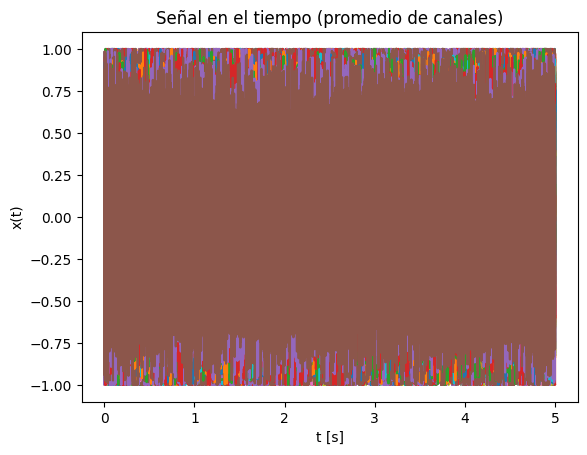

In [23]:
import matplotlib.pyplot as plt

# cálculo de Fourier por segmento y promedio de canales
vf = np.fft.rfftfreq(x_t.shape[1], 1/fs)                     # vector de frecuencias
Xw = np.fft.rfft(x_t, axis=1).mean(axis=-1)                  # FFT real sobre el tiempo, promedio en canales
print("Forma de Xw:", Xw.shape)

# Graficas de tiempo y frecuencia
plt.figure()
plt.plot(np.arange(0, x_t.shape[1]) / fs, x_t.mean(axis=-1).T)
plt.xlabel('t [s]')
plt.ylabel('x(t)')
plt.title('Señal en el tiempo (promedio de canales)')
plt.show()


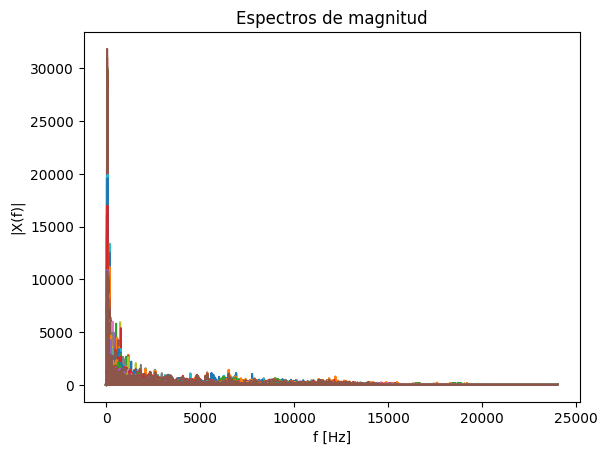

In [24]:
plt.figure()
plt.plot(vf, np.abs(Xw).T)
plt.xlabel('f [Hz]')
plt.ylabel('|X(f)|')
plt.title('Espectros de magnitud')
plt.show()

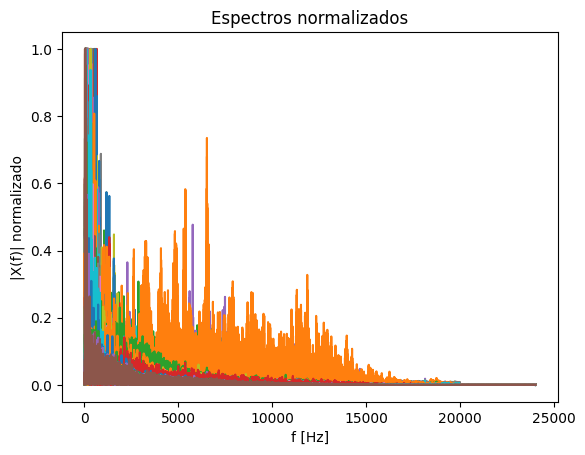

In [25]:
# Normalización entre 0 y 1 para evitar inconsistencias por amplitudes máximas
from sklearn.preprocessing import MinMaxScaler
sca = MinMaxScaler()
Xw_ = sca.fit_transform(np.abs(Xw).T).T   # normalizar por columnas (segmentos)
plt.figure()
plt.plot(vf, Xw_.T)
plt.xlabel('f [Hz]')
plt.ylabel('|X(f)| normalizado')
plt.title('Espectros normalizados')
plt.show()

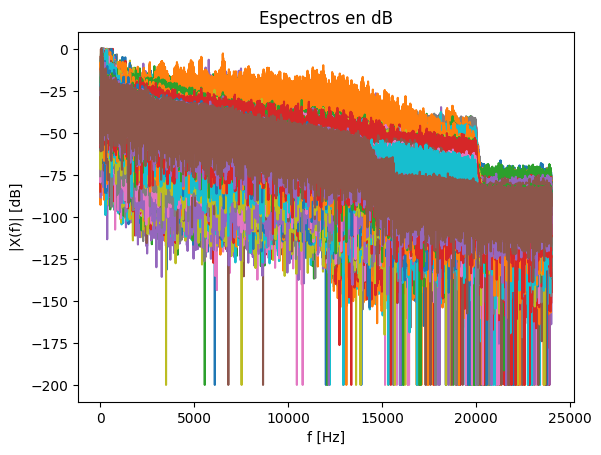

In [26]:
# En dB
plt.figure()
plt.plot(vf, (20*np.log10(Xw_ + 1e-10)).T)
plt.xlabel('f [Hz]')
plt.ylabel('|X(f)| [dB]')
plt.title('Espectros en dB')
plt.show()

#8. Visualización 2D con UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


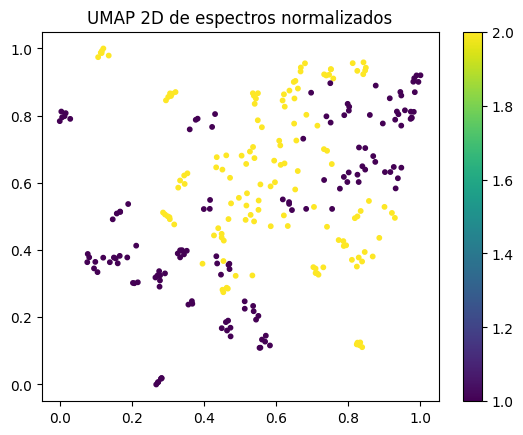

In [27]:
from umap import UMAP
from sklearn.preprocessing import MinMaxScaler

# UMAP a 2D para visualizar separabilidad
n_neighbors = max(2, int(2*np.sqrt(Xw_.shape[0])))
red_ = UMAP(n_components=2, n_neighbors=n_neighbors, random_state=42)
X_2D = red_.fit_transform(Xw_)  # Xw_ ya está normalizado
X_2D = MinMaxScaler().fit_transform(X_2D)

plt.figure()
plt.scatter(X_2D[:,0], X_2D[:,1], c=label.ravel(), s=10)
plt.colorbar()
plt.title('UMAP 2D de espectros normalizados')
plt.show()


/tmp/ipython-input-640974715.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cidx = int(label[i]-1) if (label[i]>0 and int(label[i]-1) < len(color_)) else 0


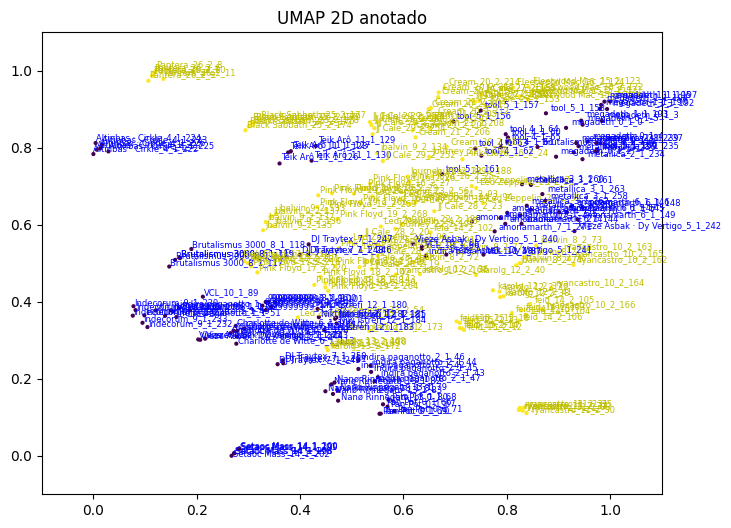

In [28]:
# Etiquetas sobre el scatter
color_ = ["b","y","g","r","c","m","k"]
plt.figure(figsize=(8,6))
plt.scatter(X_2D[:,0], X_2D[:,1], c=label.ravel(), s=4)
for i, tex in enumerate(name_c):
    cidx = int(label[i]-1) if (label[i]>0 and int(label[i]-1) < len(color_)) else 0
    plt.text(X_2D[i,0]*1.01, X_2D[i,1]*1.01, f"{tex}_{i}", fontsize=6, color=color_[cidx])
plt.xlim([-0.1,1.1]); plt.ylim([-0.1,1.1])
plt.title('UMAP 2D anotado')
plt.show()

#9. Reproducir un segmento de audio

In [29]:
from IPython.display import Audio

i_demo = 0  # índice de segmento a reproducir
print("Segmento:", i_demo, " etiqueta:", label[i_demo])
Audio(x_t[i_demo].T, rate=fs)


Segmento: 0  etiqueta: [1]


#10. Clasificador KNN sobre espectros normalizados

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Clasificador KNN con k=5 como en el enunciado
model = KNeighborsClassifier(n_neighbors=5)

# Validación cruzada en 5 folds
if len(np.unique(label)) >= 2 and len(label) >= 5:
    scores = cross_val_score(model, Xw_, label.ravel(), cv=5, scoring='accuracy')
    print("Acierto por fold:", scores)
    print("Acierto promedio:", scores.mean())
    print("Desviación estándar:", scores.std())
else:
    print("No hay suficientes muestras o clases para hacer validación cruzada.")

# Entrenar modelo con todos los datos disponibles
model.fit(Xw_, label.ravel())
print("Modelo KNN entrenado.")


Acierto por fold: [0.71428571 0.78181818 0.58181818 0.81818182 0.63636364]
Acierto promedio: 0.7064935064935065
Desviación estándar: 0.08794423170414334
Modelo KNN entrenado.


#11. Guardar el modelo y descargarlo

In [ ]:
import joblib
import shutil
from datetime import datetime
from google.colab import files

# Crear carpeta del modelo
os.makedirs('modelo', exist_ok=True)

# Guardar objeto con todo lo necesario para reutilizar
filename_ = 'modelo/reggaeton_vs_metal'
model_ = {
    'Xw_': Xw_,
    'label': label,
    'name_c': name_c,
    'vf': vf,
    'fs': fs,
    'modelo': model,
    'type': X['type'].astype(str).unique()
}
joblib.dump(model_, filename_ + ".pkl")

# Comprimir y descargar
namefile = datetime.now().strftime("%Y_%m_%d_%H_%M_%S") + "_modelo"
shutil.make_archive(namefile, 'zip', 'modelo')
files.download(namefile + '.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#12. Cargar el modelo y hacer una predicción de ejemplo

In [ ]:
# Cargar modelo desde el archivo generado
my_model_loaded = joblib.load(filename_ + ".pkl")
print("Claves del modelo:", my_model_loaded.keys())

# Predicción para un espectro ya calculado (primer segmento)
pred_ = my_model_loaded['modelo'].predict(Xw_[0].reshape(1,-1))[0]
print('Etiqueta estimada: ', my_model_loaded['type'][int(pred_-1)] if pred_>0 else pred_)
print('Etiqueta original: ', my_model_loaded['type'][int(my_model_loaded['label'][0][0])-1] if my_model_loaded['label'][0][0]>0 else my_model_loaded['label'][0][0])
